# Stat 248 Final Project: Apple Volatility Forecasting

**Question.** Can Apple daily return volatility be explained and forecast using its own recent returns, trading volume, and broader market volatility?

I use this notebook as the main code report for the project. The analysis starts from the raw CSV files, lines up the three daily time series, builds volatility measures, and then compares a regression-based forecast with a GARCH model.


## 1. Data and Setup

The project uses three daily datasets in the same folder as this notebook: AAPL prices and volume from MacroTrends, S&P 500 levels, and VIX closes. After merging them by date, the usable sample runs from 2016 to 2026.


In [13]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path(".")
REQUIRED_DATA_FILES = [
    "MacroTrends_Data_Download_AAPL.csv",
    "SP500.csv",
    "VIXCLS.csv",
]
missing = [file for file in REQUIRED_DATA_FILES if not (DATA_DIR / file).exists()]
if missing:
    raise FileNotFoundError(
        "Missing data files in the current folder: " + ", ".join(missing)
    )
DATA_DIR


PosixPath('.')

In [14]:
def load_project_data(base=DATA_DIR):
    aapl = pd.read_csv(base / "MacroTrends_Data_Download_AAPL.csv", skiprows=14)
    aapl["date"] = pd.to_datetime(aapl["date"])
    aapl = aapl.sort_values("date")
    for col in ["open", "high", "low", "close", "volume"]:
        aapl[col] = pd.to_numeric(aapl[col], errors="coerce")

    sp500 = pd.read_csv(base / "SP500.csv")
    sp500["date"] = pd.to_datetime(sp500["observation_date"])
    sp500["sp500"] = pd.to_numeric(sp500["SP500"], errors="coerce")
    sp500 = sp500[["date", "sp500"]]

    vix = pd.read_csv(base / "VIXCLS.csv")
    vix["date"] = pd.to_datetime(vix["observation_date"])
    vix["vix"] = pd.to_numeric(vix["VIXCLS"], errors="coerce")
    vix = vix[["date", "vix"]]

    df = aapl.merge(sp500, on="date", how="inner").merge(vix, on="date", how="inner")
    df = df.dropna(subset=["close", "volume", "sp500", "vix"]).reset_index(drop=True)
    df = df[df["date"] >= "2016-05-03"].copy()
    df["aapl_return"] = 100 * np.log(df["close"]).diff()
    df["sp500_return"] = 100 * np.log(df["sp500"]).diff()
    df["abs_aapl_return"] = df["aapl_return"].abs()
    df["sq_aapl_return"] = df["aapl_return"] ** 2
    df["abs_sp500_return"] = df["sp500_return"].abs()
    df["log_volume"] = np.log(df["volume"])
    roll_mean = df["log_volume"].rolling(252, min_periods=40).mean()
    roll_sd = df["log_volume"].rolling(252, min_periods=40).std()
    df["volume_z"] = (df["log_volume"] - roll_mean) / roll_sd
    df["rv_21"] = df["aapl_return"].rolling(21).std() * np.sqrt(252)
    df["log_sq_return"] = np.log(df["sq_aapl_return"] + 1e-4)
    df["lag_log_sq_return"] = df["log_sq_return"].shift(1)
    df["lag_abs_return"] = df["abs_aapl_return"].shift(1)
    df["lag_volume_z"] = df["volume_z"].shift(1)
    df["lag_abs_sp500_return"] = df["abs_sp500_return"].shift(1)
    df["lag_vix"] = df["vix"].shift(1)
    return df.dropna().reset_index(drop=True)

df = load_project_data()
df.head(), df.tail(), df.shape

(        date     open     high      low    close    volume    sp500    vix  \
 0 2016-06-29  21.4119  21.5441  21.3344  21.5099  33295685  2070.77  16.64   
 1 2016-06-30  21.5191  21.8221  21.4872  21.7834  32662704  2098.86  15.63   
 2 2016-07-01  21.7583  21.9816  21.7218  21.8494  23721490  2102.95  14.77   
 3 2016-07-05  21.7355  21.7378  21.5236  21.6444  25251603  2088.55  15.58   
 4 2016-07-06  21.5555  21.7970  21.5031  21.7674  28208162  2099.73  14.96   
 
    aapl_return  sp500_return  ...  abs_sp500_return  log_volume  volume_z  \
 0     0.861444      1.688922  ...          1.688922   17.320938 -0.061900   
 1     1.263492      1.347382  ...          1.347382   17.301744 -0.125341   
 2     0.302525      0.194678  ...          0.194678   16.981892 -1.186070   
 3    -0.942670     -0.687108  ...          0.687108   17.044400 -0.951832   
 4     0.566668      0.533872  ...          0.533872   17.155122 -0.565919   
 
        rv_21  log_sq_return  lag_log_sq_return  lag_a

## 2. Exploratory Time-Series Analysis

I start by looking at price, daily returns, and a smoother 21-day realized volatility measure. The return series itself moves around zero, but the size of the returns clearly changes over time, which is the pattern I want the models to capture.


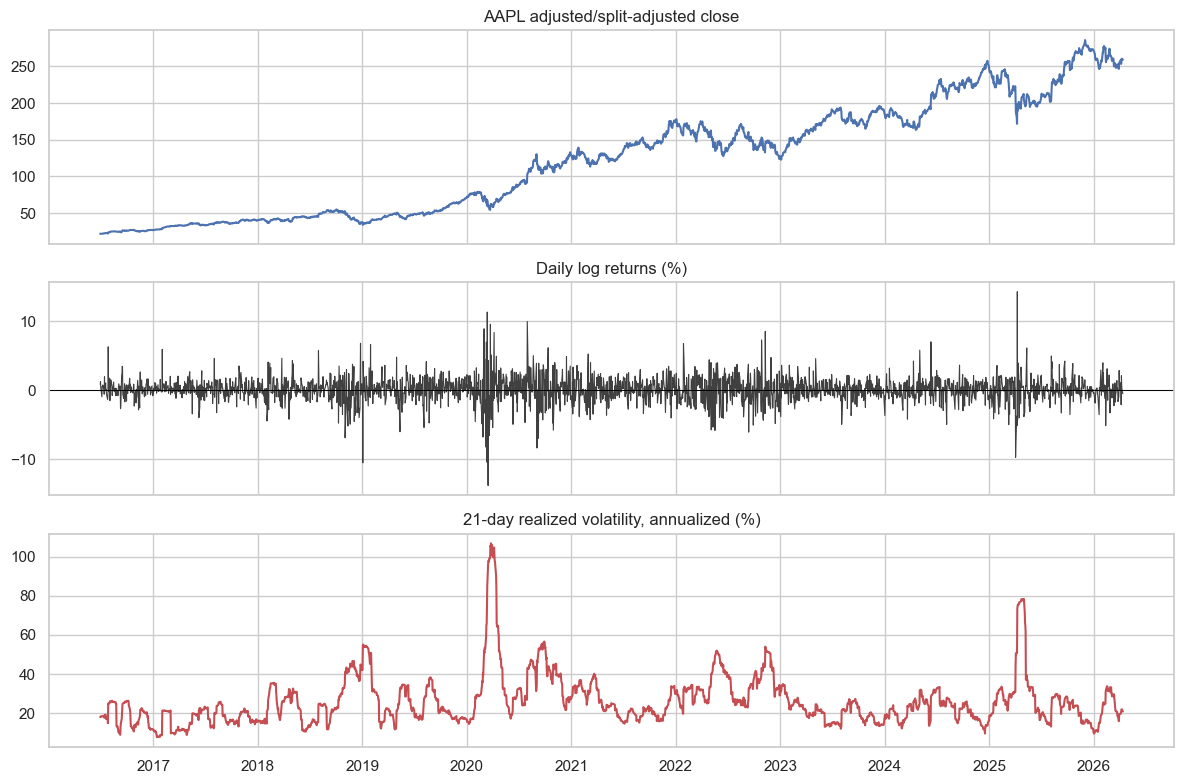

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df["date"], df["close"])
ax[0].set_title("AAPL adjusted/split-adjusted close")
ax[1].plot(df["date"], df["aapl_return"], color="0.25", linewidth=0.8)
ax[1].axhline(0, color="black", linewidth=0.7)
ax[1].set_title("Daily log returns (%)")
ax[2].plot(df["date"], df["rv_21"], color="#c44e52")
ax[2].set_title("21-day realized volatility, annualized (%)")
plt.tight_layout()

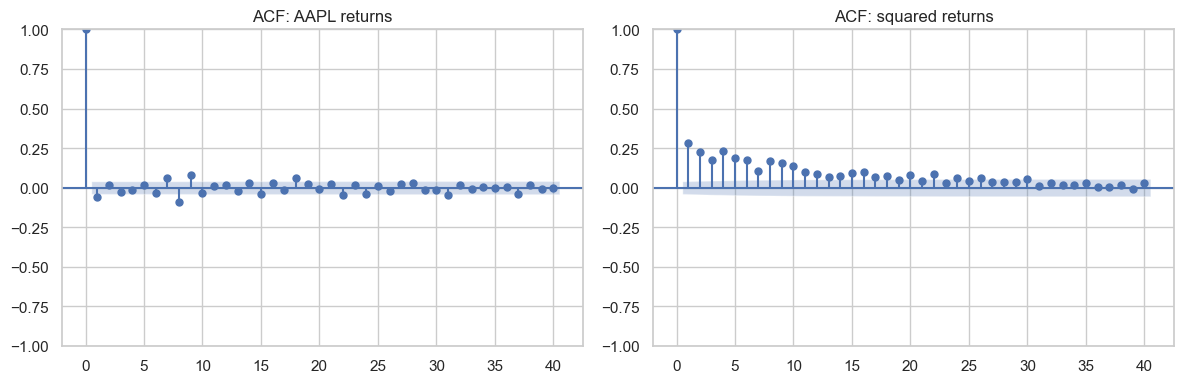

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sm.graphics.tsa.plot_acf(df["aapl_return"], lags=40, ax=ax[0], title="ACF: AAPL returns")
sm.graphics.tsa.plot_acf(df["sq_aapl_return"], lags=40, ax=ax[1], title="ACF: squared returns")
plt.tight_layout()

The ACF plots show the usual financial time-series pattern. Raw returns have little autocorrelation, so the direction of tomorrow's return is hard to predict. Squared returns are more persistent, which suggests volatility clustering.


In [17]:
adf_rows = []
for name in ["aapl_return", "sq_aapl_return", "rv_21", "log_volume", "vix"]:
    x = df[name].dropna()
    stat, p, usedlag, nobs, *_ = adfuller(x, autolag="AIC")
    adf_rows.append({"Series": name, "ADF statistic": stat, "p-value": p, "lags": usedlag, "n": nobs})
adf_table = pd.DataFrame(adf_rows)
adf_table

,Series,ADF statistic,p-value,lags,n
0,aapl_return,-16.303856,3.246143e-29,8,2451
1,sq_aapl_return,-10.535739,8.911201e-19,8,2451
2,rv_21,-5.602991,1.252438e-06,27,2432
3,log_volume,-2.475456,1.215610e-01,27,2432
4,vix,-5.224043,7.850884e-06,9,2450


## 3. Dynamic Regression for Volatility

For the regression part, I use next-day log squared return as a noisy one-day volatility measure. The baseline model only uses yesterday's log squared return. The fuller ARX model adds yesterday's absolute AAPL return, abnormal trading volume, absolute S&P 500 return, and VIX. I use HAC standard errors because the residuals may still have some serial dependence.


In [18]:
target = "log_sq_return"
features_base = ["lag_log_sq_return"]
features_full = ["lag_log_sq_return", "lag_abs_return", "lag_volume_z", "lag_abs_sp500_return", "lag_vix"]
split = int(len(df) * 0.8)
train, test = df.iloc[:split].copy(), df.iloc[split:].copy()

def fit_ols(cols):
    X = sm.add_constant(train[cols])
    return sm.OLS(train[target], X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

m_base = fit_ols(features_base)
m_full = fit_ols(features_full)
print(m_full.summary())

                            OLS Regression Results                            
Dep. Variable:          log_sq_return   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     40.05
Date:                Thu, 14 May 2026   Prob (F-statistic):           2.63e-39
Time:                        08:38:21   Log-Likelihood:                -4410.3
No. Observations:                1968   AIC:                             8833.
Df Residuals:                    1962   BIC:                             8866.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.1573 

In [19]:
pred_base = m_base.predict(sm.add_constant(test[features_base]))
pred_full = m_full.predict(sm.add_constant(test[features_full]))
actual_var = test["sq_aapl_return"]

metrics = pd.DataFrame({
    "Model": ["AR log-volatility", "ARX log-volatility"],
    "Test RMSE vs squared return": [
        np.sqrt(mean_squared_error(actual_var, np.exp(pred_base))),
        np.sqrt(mean_squared_error(actual_var, np.exp(pred_full))),
    ],
    "Test MAE vs squared return": [
        mean_absolute_error(actual_var, np.exp(pred_base)),
        mean_absolute_error(actual_var, np.exp(pred_full)),
    ],
    "Correlation with squared return": [
        np.corrcoef(actual_var, np.exp(pred_base))[0, 1],
        np.corrcoef(actual_var, np.exp(pred_full))[0, 1],
    ],
})
metrics

,Model,Test RMSE vs squared return,Test MAE vs squared return,Correlation with squared return
0,AR log-volatility,11.672386,2.984022,0.166859
1,ARX log-volatility,10.947308,2.887742,0.617278


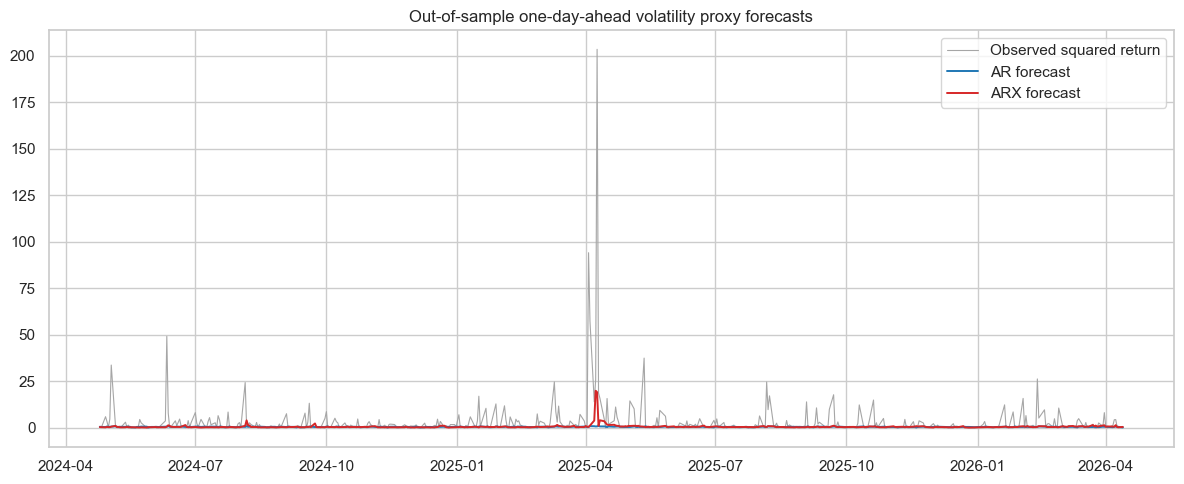

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test["date"], actual_var, color="0.65", linewidth=0.8, label="Observed squared return")
ax.plot(test["date"], np.exp(pred_base), color="#1f77b4", linewidth=1.4, label="AR forecast")
ax.plot(test["date"], np.exp(pred_full), color="#d62728", linewidth=1.4, label="ARX forecast")
ax.set_title("Out-of-sample one-day-ahead volatility proxy forecasts")
ax.legend()
plt.tight_layout()

## 4. GARCH(1,1) Conditional Volatility Model

The regression models try to predict an observed volatility proxy. GARCH takes a different approach: it treats volatility as a latent conditional variance that updates after each return shock. I implement the GARCH(1,1) likelihood directly so the notebook can run without requiring the external `arch` package.


In [21]:
def fit_garch11(returns):
    r = np.asarray(returns.dropna(), dtype=float)
    mu0 = r.mean()
    omega0 = r.var() * 0.05
    x0 = np.array([mu0, omega0, 0.08, 0.90])
    bounds = [(None, None), (1e-8, None), (1e-6, 0.999), (1e-6, 0.999)]

    def nll(params):
        mu, omega, alpha, beta = params
        if alpha + beta >= 0.999:
            return 1e12
        eps = r - mu
        h = np.empty_like(r)
        h[0] = max(np.var(eps), 1e-6)
        for t in range(1, len(r)):
            h[t] = omega + alpha * eps[t - 1] ** 2 + beta * h[t - 1]
            if h[t] <= 0 or not np.isfinite(h[t]):
                return 1e12
        return 0.5 * np.sum(np.log(2 * np.pi) + np.log(h) + eps**2 / h)

    res = minimize(nll, x0, bounds=bounds, method="Nelder-Mead", options={"maxiter": 6000})
    if not res.success:
        res = minimize(nll, res.x, bounds=bounds, method="L-BFGS-B", options={"maxiter": 6000})

    mu, omega, alpha, beta = res.x
    eps = r - mu
    h = np.empty_like(r)
    h[0] = max(np.var(eps), 1e-6)
    for t in range(1, len(r)):
        h[t] = omega + alpha * eps[t - 1] ** 2 + beta * h[t - 1]
    z = eps / np.sqrt(h)
    params = pd.Series({"mu": mu, "omega": omega, "alpha": alpha, "beta": beta, "alpha+beta": alpha + beta})
    return params, pd.Series(h, index=returns.dropna().index), pd.Series(z, index=returns.dropna().index), res.fun

garch_params, garch_var, z, nll = fit_garch11(df["aapl_return"])
garch_params

mu            0.161277
omega         0.144743
alpha         0.108131
beta          0.847222
alpha+beta    0.955354
dtype: float64

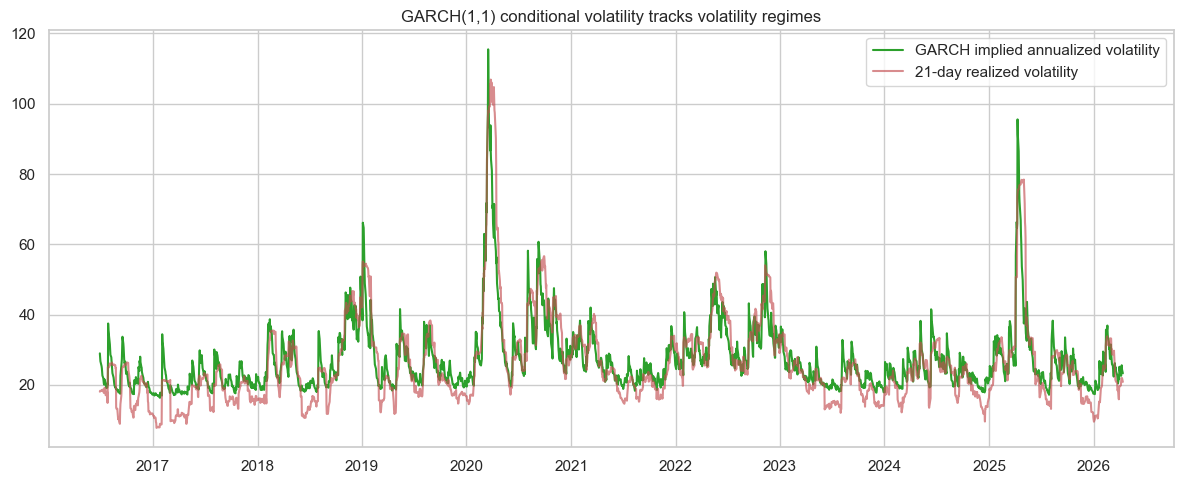

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.loc[garch_var.index, "date"], np.sqrt(garch_var * 252), color="#2ca02c", label="GARCH implied annualized volatility")
ax.plot(df["date"], df["rv_21"], color="#c44e52", alpha=0.65, label="21-day realized volatility")
ax.set_title("GARCH(1,1) conditional volatility tracks volatility regimes")
ax.legend()
plt.tight_layout()

## 5. Diagnostics

I use diagnostics to check whether the models are actually removing the main time-series structure. For the regression model, I look at residual autocorrelation and Ljung-Box tests. For the volatility model, I test for ARCH effects in the raw returns and inspect the standardized GARCH residuals.


In [23]:
lb = acorr_ljungbox(m_full.resid, lags=[10, 20], return_df=True)
arch_lm = het_arch(df["aapl_return"].dropna(), nlags=10)
print("Ljung-Box test on ARX residuals")
display(lb)
print(f"ARCH LM p-value for raw AAPL returns: {arch_lm[1]:.4g}")

Ljung-Box test on ARX residuals


,lb_stat,lb_pvalue
10,14.541593,0.149690
20,33.891668,0.026867


ARCH LM p-value for raw AAPL returns: 4.164e-70


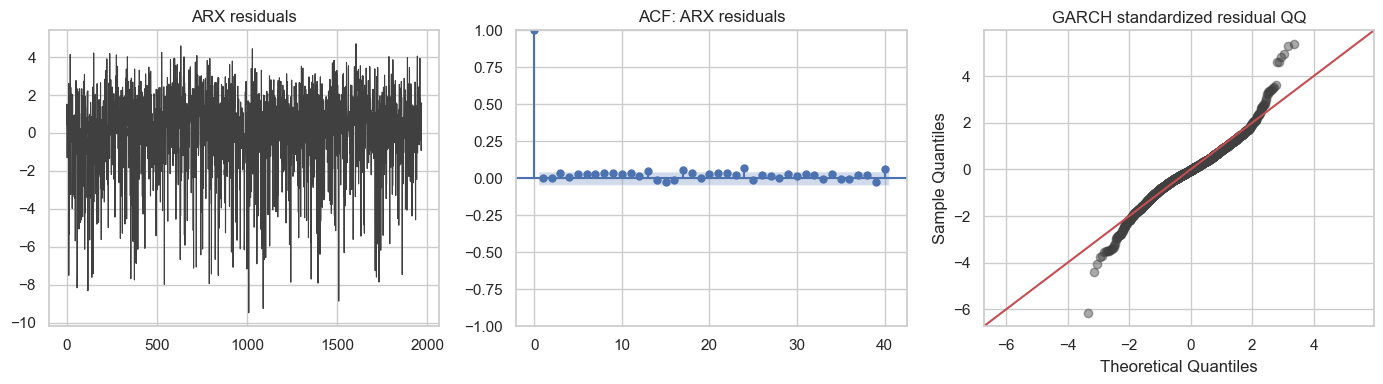

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(m_full.resid.index, m_full.resid, color="0.25", linewidth=0.8)
ax[0].set_title("ARX residuals")
sm.graphics.tsa.plot_acf(m_full.resid, lags=40, ax=ax[1], title="ACF: ARX residuals")
sm.qqplot(z.dropna(), line="45", ax=ax[2], markerfacecolor="0.25", markeredgecolor="0.25", alpha=0.45)
ax[2].set_title("GARCH standardized residual QQ")
plt.tight_layout()

## 6. Interpretation

The clearest result is that AAPL volatility clusters over time. The ACF of squared returns and the ARCH test point in the same direction, and the GARCH estimate has high persistence with \(\alpha + \beta\) around 0.96. In plain terms, large volatility shocks tend to fade slowly rather than disappear the next day.

The ARX regression also suggests that market-wide risk matters. Lagged VIX and abnormal trading volume are the most useful predictors in the fuller model, and the ARX forecast improves on the simple autoregressive forecast in the test period. The S&P 500 shock coefficient is harder to interpret because VIX is already in the model, so I would not put too much weight on that coefficient by itself.

Overall, the answer to my question is partly yes. AAPL volatility is not just random day-to-day noise; it has persistent structure and is related to market conditions. At the same time, exact one-day squared returns are very noisy, so these forecasts should be read as rough volatility signals rather than precise predictions.
